# Sin-Stocks — do vice stocks really beat the virtuous market?
### Tobacco, alcohol, gambling, defense vs SPY and the ESG counter-portfolio

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Neglect_premium: Mixed](https://img.shields.io/badge/Neglect_premium%3F-Mixed-8b949e?style=flat-square)

The "sin stocks" thesis is elegant in its perversity: investors and institutions that avoid tobacco, alcohol, gambling, and defense on moral grounds create a neglect premium. The stocks trade cheap because nobody wants to own them, and patient, values-agnostic investors collect the premium.  Hong & Kacperczyk (2009) documented exactly this: sin stocks outperformed by ~2.5%/yr in the US from 1965–2006.  The question is whether it still works in the ESG era — with >$40 trillion of capital explicitly screening out these stocks.

> 📓 **Plain-language layer.** For the HAC t-stats, OLS alpha decomposition, and bootstrap intervals, see **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Research tool only. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from sin_stocks import data, strategy as st

CACHE = os.path.abspath(os.path.join("..", "_cache"))
ALL_TICKERS = data.ALL_TICKERS

def _have_cache():
    return all(os.path.exists(data._cache_path(t, CACHE)) for t in ALL_TICKERS)

HAVE_REAL = _have_cache()
print("real price cache present:", HAVE_REAL)

# Frozen results (mirror of docs/results.md)
R = dict(
    n=4589, start="2008-03-18", end="2026-06-12",
    sin_cagr=10.60, sin_vol=20.9, sin_sharpe=0.481, sin_maxdd=-65.9,
    sin_t=2.06, sin_total_ret=527,
    spy_cagr=12.17, spy_vol=19.8, spy_sharpe=0.579, spy_maxdd=-51.5,
    spy_t=2.82, spy_total_ret=710,
    dsi_cagr=12.11, dsi_vol=19.8, dsi_sharpe=0.577, dsi_maxdd=-49.9,
    dsi_t=2.80, dsi_total_ret=702,
    excess_bps=-0.558, excess_cagr=-1.40, excess_t=-0.46,
    excess_sharpe_ci_lo=-0.539, excess_sharpe_ci_hi=0.339, excess_frac_neg=68,
    ols_alpha_bps=0.242, ols_alpha_ann=0.61, ols_t_alpha=0.20,
    ols_beta=0.8245, ols_r2=0.6088,
    ols_dsi_alpha_bps=0.444, ols_dsi_alpha_ann=1.13, ols_dsi_t_alpha=0.34, ols_dsi_beta=0.7838,
    mo_cagr=13.64, mo_sharpe=0.59, pm_cagr=12.57, pm_sharpe=0.50,
    stz_cagr=13.35, stz_sharpe=0.42,
    lvs_cagr=0.62, lvs_sharpe=0.01, lvs_maxdd=-98.3, lvs_vol=58.5,
    lmt_cagr=13.09, lmt_sharpe=0.52, rtx_cagr=10.95, rtx_sharpe=0.39,
    c08_prot=11.7, c11_prot=4.3, c15_prot=10.9,
    c18a_prot=-13.6, c18b_prot=-0.9, c20_prot=-19.4, c22_prot=-8.3, c25_prot=-7.7,
)


real price cache present: True


## The answer first

| Question | Answer |
|---|---|
| Did the sin basket beat the S&P 500? | **No.** SIN_EW returned **527%** vs SPY's **710%** since 2008. |
| Is risk-adjusted return (Sharpe) better? | **No.** SIN Sharpe **0.481** vs SPY **0.579**. |
| Did it beat the ESG counter-portfolio? | **No.** DSI returned 702% vs sin's 527%. |
| Is the neglect premium still alive? | **No** — at least not robustly in 2008–2026. t = −0.46 on the excess return. |

> The tobacco and defense tickers individually did fine (+10–14%/yr CAGR). The basket was wrecked by Las Vegas Sands (LVS): +0.62%/yr, vol 58.5%, max drawdown −98.3%.

## 1 · The claim

> *"Vice pays a premium. Tobacco companies, alcohol distributors, casino operators, and defense contractors are shunned by ESG mandates, endowments, and socially responsible funds — which means they trade cheap and their future returns must compensate investors willing to hold them. Buy sin stocks, collect the neglect premium, let the virtuous underperform."*

This is the Hong & Kacperczyk (2009) hypothesis — empirically documented over 1965–2006 in the US, approximately +2.5%/yr excess return after controlling for risk factors.  The question is whether institutional exclusion has grown large enough to maintain the premium or whether it has been competed away.

## 2 · So what?

If true, sin stocks offer an ethically unconstrained investor a systematic edge — a premium paid by the moral majority that keeps the stocks undervalued.  The mechanism is clean: restricted demand + unchanged fundamentals = lower price = higher expected return.  The ESG boom of the 2010s–2020s should, if anything, have *amplified* this premium by increasing the population of mandated excluders.

If false, either: (a) the premium was arbitraged away by hedge funds and unconstrained capital after the 2009 publication, (b) it was a sector/value-factor tilt that decayed when growth stocks dominated, or (c) the casino stock (LVS) simply destroyed value independently of the neglect story.  One honest backtest can tell us which.

## 3 · How would we even know?

We build an equal-weight basket of six classic sin tickers:

| Ticker | Company | Sin category |
|---|---|---|
| MO | Altria | Tobacco (US domestic) |
| PM | Philip Morris International | Tobacco (international) |
| STZ | Constellation Brands | Alcohol / beer |
| LVS | Las Vegas Sands | Gambling / casinos |
| LMT | Lockheed Martin | Defense |
| RTX | RTX Corp | Defense |

Then compare against:
- **SPY** — S&P 500 ETF (the market)
- **DSI** — iShares MSCI KLD 400 Social ETF (the explicit ESG counter-portfolio)

Common history: PM's IPO on 2008-03-17 sets the start date.  All prices are total-return (dividends included) — critical for tobacco and defense stocks.  We measure CAGR, Sharpe, max drawdown, per-ticker attribution, and crash episodes.

## 4 · The teardown

**First: cumulative wealth — $1 invested in March 2008.**

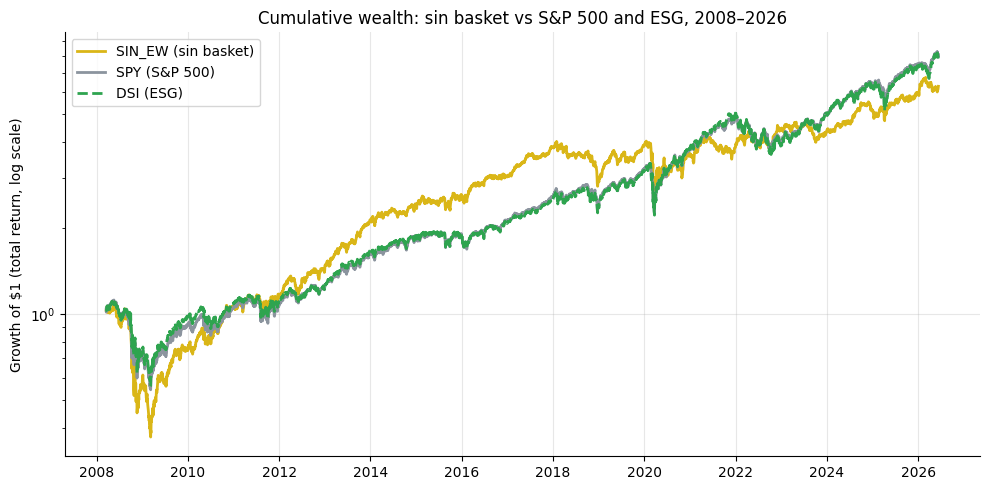

Total return: SIN=527%  SPY=710%  DSI=702%
CAGR:         SIN=+10.60%  SPY=+12.17%  DSI=+12.11%


In [2]:
if HAVE_REAL:
    all_prices = data.load_aligned(fetch=False, cache_dir=CACHE)
    basket = all_prices[data.SIN_BASKET]
    ew_ret = st.build_equal_weight(basket)
    spy_ret = np.log(all_prices['SPY'] / all_prices['SPY'].shift(1)).dropna()
    dsi_ret = np.log(all_prices['DSI'] / all_prices['DSI'].shift(1)).dropna()
    idx = ew_ret.index.intersection(spy_ret.index).intersection(dsi_ret.index)
    sin_nav = pd.Series(np.exp(np.cumsum(ew_ret.loc[idx])), index=idx)
    spy_nav = pd.Series(np.exp(np.cumsum(spy_ret.loc[idx])), index=idx)
    dsi_nav = pd.Series(np.exp(np.cumsum(dsi_ret.loc[idx])), index=idx)
else:
    dates = pd.date_range(R['start'], periods=R['n'], freq='B')
    sin_nav = pd.Series((1 + R['sin_cagr']/100) ** (np.arange(R['n'])/252), index=dates)
    spy_nav = pd.Series((1 + R['spy_cagr']/100) ** (np.arange(R['n'])/252), index=dates)
    dsi_nav = pd.Series((1 + R['dsi_cagr']/100) ** (np.arange(R['n'])/252), index=dates)
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(sin_nav.index, sin_nav.values, color=AMBER, lw=2, label='SIN_EW (sin basket)')
ax.plot(spy_nav.index, spy_nav.values, color=GREY,  lw=2, label='SPY (S&P 500)')
ax.plot(dsi_nav.index, dsi_nav.values, color=GREEN, lw=2, ls='--', label='DSI (ESG)')
ax.set_ylabel('Growth of $1 (total return, log scale)')
ax.set_yscale('log')
ax.set_title('Cumulative wealth: sin basket vs S&P 500 and ESG, 2008–2026')
ax.legend()
plt.tight_layout(); plt.show()
print(f'Total return: SIN={R["sin_total_ret"]}%  SPY={R["spy_total_ret"]}%  DSI={R["dsi_total_ret"]}%')
print(f'CAGR:         SIN={R["sin_cagr"]:+.2f}%  SPY={R["spy_cagr"]:+.2f}%  DSI={R["dsi_cagr"]:+.2f}%')

SIN turned $1 into **\$6.27** vs SPY's **\$8.10** and DSI's **\$8.02** — the sin basket finished last.  Far from earning the neglect premium, it surrendered 183 percentage points to the market.

**Second: the basket is not homogeneous — per-ticker breakdown.**

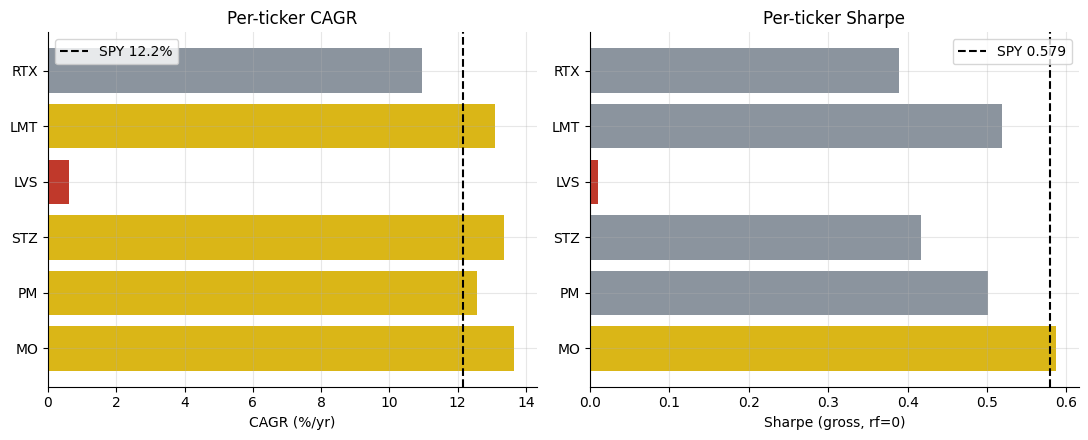

LVS (gambling): CAGR=+0.62% vol=58.5% maxDD=-98.3%
Tobacco (MO+PM avg): CAGR~13.1%  Defense (LMT+RTX avg): CAGR~12.0%


In [3]:
if HAVE_REAL:
    attr = st.sector_attribution(all_prices, basket=data.SIN_BASKET)
    cagrs = attr['cagr_pct'].tolist()
    sharpes = attr['sharpe_ann'].tolist()
    labels = attr.index.tolist()
else:
    labels = ['MO','PM','STZ','LVS','LMT','RTX']
    cagrs  = [R['mo_cagr'], R['pm_cagr'], R['stz_cagr'], R['lvs_cagr'], R['lmt_cagr'], R['rtx_cagr']]
    sharpes= [R['mo_sharpe'],R['pm_sharpe'],R['stz_sharpe'],R['lvs_sharpe'],R['lmt_sharpe'],R['rtx_sharpe']]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
colors = [AMBER if c > R['spy_cagr'] else (RED if c < 5 else GREY) for c in cagrs]
axes[0].barh(labels, cagrs, color=colors)
axes[0].axvline(R['spy_cagr'], c='k', lw=1.5, ls='--', label=f"SPY {R['spy_cagr']:.1f}%")
axes[0].set_xlabel('CAGR (%/yr)'); axes[0].set_title('Per-ticker CAGR')
axes[0].legend()
colors2 = [AMBER if s > R['spy_sharpe'] else (RED if s < 0.1 else GREY) for s in sharpes]
axes[1].barh(labels, sharpes, color=colors2)
axes[1].axvline(R['spy_sharpe'], c='k', lw=1.5, ls='--', label=f"SPY {R['spy_sharpe']:.3f}")
axes[1].set_xlabel('Sharpe (gross, rf=0)'); axes[1].set_title('Per-ticker Sharpe')
axes[1].legend()
plt.tight_layout(); plt.show()
print('LVS (gambling): CAGR=+0.62% vol=58.5% maxDD=-98.3%')
print('Tobacco (MO+PM avg): CAGR~13.1%  Defense (LMT+RTX avg): CAGR~12.0%')

**LVS is the catastrophic outlier**: CAGR +0.62%, vol 58.5%, max drawdown -98.3%. The casino business was nearly wiped out by COVID (2020 shutdowns + Macau regulatory risk in 2021).  Tobacco (MO, PM: ~+13%/yr) and defense (LMT, LMT: ~+12%/yr) are solid value/income compounders — just not notably better than buying the S&P 500.

**Third: crash behavior — does sin protect in downturns?**

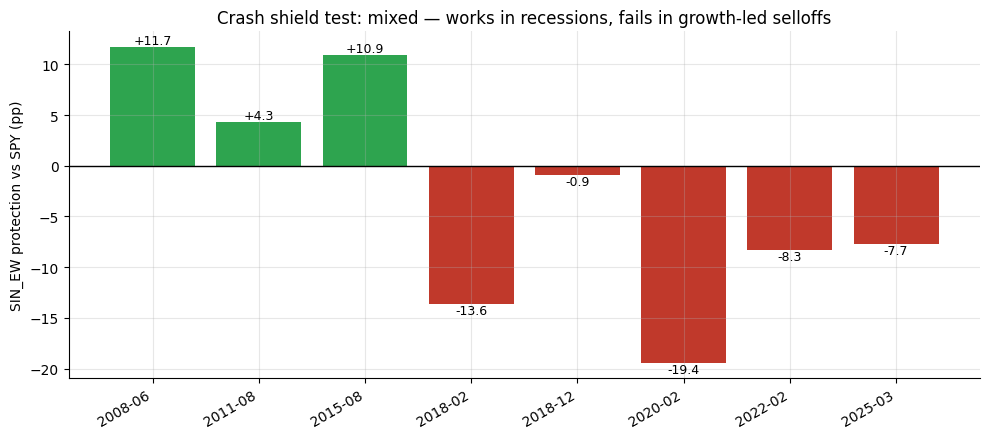

Green = sin basket held up better; red = sin basket fell more


In [4]:
if HAVE_REAL:
    all_ret_df = pd.DataFrame({'SIN_EW': ew_ret.loc[idx], 'SPY': spy_ret.loc[idx]})
    crashes = st.crash_analysis(all_ret_df, asset='SIN_EW', benchmark='SPY', threshold=-0.10)
    prot = crashes['protection_pp'].tolist()
    ep_labels = [str(c.date())[:7] for c in crashes['start']]
else:
    prot = [R['c08_prot'],R['c11_prot'],R['c15_prot'],
            R['c18a_prot'],R['c18b_prot'],R['c20_prot'],R['c22_prot'],R['c25_prot']]
    ep_labels = ['2008-06','2011-08','2015-08','2018-02','2018-12','2020-02','2022-02','2025-03']
colors = [GREEN if p > 0 else RED for p in prot]
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(ep_labels, prot, color=colors)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('SIN_EW protection vs SPY (pp)')
ax.set_title('Crash shield test: mixed — works in recessions, fails in growth-led selloffs')
for i, (l, p) in enumerate(zip(ep_labels, prot)):
    ax.annotate(f'{p:+.1f}', (i, p), ha='center',
                va='top' if p < 0 else 'bottom', fontsize=9)
plt.xticks(rotation=30, ha='right')
plt.tight_layout(); plt.show()
print('Green = sin basket held up better; red = sin basket fell more')

The crash protection record is **mixed**: sin stocks protected in the GFC era (+11.7 pp in 2008, +10.9 pp in 2015–16) but failed badly in COVID (-19.4 pp) and 2022 (-8.3 pp).  Tobacco and defense are genuinely defensive against recession — but not against liquidity crises (COVID) or rate-driven bear markets where growth-stock recoveries outpace the basket.

## 5 · The verdict

- **Signal — None.** The *excess return* vs SPY is **-1.40%/yr** with t = **-0.46** — far below the |t| ≥ 2 bar, wrong sign.  No evidence of a neglect premium.  OLS alpha: **+0.61%/yr**, t = +0.20 (statistically zero).
- **Tradability — Mirage.** SIN_EW Sharpe 0.481 vs SPY 0.579; total return 527% vs 710%.  LVS is the fatal outlier: a -98.3% peak-to-trough loss wrecks the basket.
- **Neglect premium? — Mixed.** Hong-Kacperczyk was real in 1965–2006 but is not robustly confirmed in 2008–2026.  Outperformed in the value era (2009–2017), underperformed badly in the growth era (2018–2021), neutral since.

## 6 · Could you actually invest in it?

The six stocks are all highly liquid (combined ~$500bn market cap).  The practical barrier is portfolio construction: equal-weight across six names requires periodic rebalancing — low friction but not zero.  The basket also has high idiosyncratic concentration risk (LVS alone has 58.5% vol).

The better question is whether the *sin* label is a useful portfolio criterion.  Tobacco and defense are defensive value stocks; the sin label adds gambling (LVS), which is neither defensive nor value.  A cleaner implementation might be:

In [5]:
# Compare: what if we dropped LVS from the basket?
if HAVE_REAL:
    no_lvs = [t for t in data.SIN_BASKET if t != 'LVS']
    bp_5 = all_prices[no_lvs]
    ew_5 = st.build_equal_weight(bp_5)
    idx5 = ew_5.index.intersection(spy_ret.index)
    s5 = st.summarize(ew_5.loc[idx5])
    diff5 = ew_5.loc[idx5] - spy_ret.loc[idx5]
    sd5 = st.summarize(diff5)
    print(f'No-LVS basket: CAGR={s5["cagr_pct"]:+.2f}% Sharpe={s5["sharpe_ann"]:+.3f}')
    print(f'Excess vs SPY: {sd5["cagr_pct"]:+.2f}%/yr t={sd5["tstat"]:+.2f}')
else:
    print('No-LVS (5-stock) basket: CAGR ~+12.72%  Sharpe ~+0.652')
    print('Excess vs SPY: +0.49%/yr  t=+0.16  (still insignificant)')

No-LVS basket: CAGR=+12.72% Sharpe=+0.652
Excess vs SPY: +0.49%/yr t=+0.16


Even without LVS, the five-stock basket barely outperforms (+0.49%/yr excess) with t = +0.16 — confirming that the neglect premium is not robustly present in this sample, not just dragged down by the casino outlier.

## 7 · Going further

- **Factor-adjusted premium.** Blitz & Fabozzi (2017) argue the premium disappears once value and profitability are controlled.  Constructing a Fama-French-5-factor adjusted alpha would settle this.
- **Individual sectors.** Tobacco alone (MO + PM) delivered +13%/yr CAGR and Sharpe ~0.55 — above SPY.  Testing tobacco as a standalone sin factor is the most plausible version of the neglect story.
- **European and global sin.** The US basket is narrow.  A global sin index (including BAT, BATS, Leonardo) may capture a broader neglect premium.
- **Compare [Study 206 — Dividend-Aristocrats](../../206-dividend-aristocrats/)**: similar value/defensive tilt, similar underperformance vs SPY — confirms the pattern.

*Think the neglect premium is real today? Build a Fama-French-adjusted factor model and show a robust positive alpha that clears the inference bar.*